<a href="https://colab.research.google.com/github/ibonetc/Data_Analytics/blob/main/EjemploRedConvolucional_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Ejemplo de Tensorflow con BD MNIST

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D, Input, BatchNormalization, AveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [ ]:
fashion_mnist=keras.datasets.fashion_mnist
(train_images, train_labels), (test_images, test_labels)=fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
class_names=['Camiseta/top', 'Pantalón', 'Suéter', 'Vestido', 'Abrigo','Sandalia', 'Camisa', 'Tenis', 'Bolsa', 'Botín']

In [ ]:
print(train_images.shape)
print(test_images.shape)

(60000, 28, 28)
(10000, 28, 28)


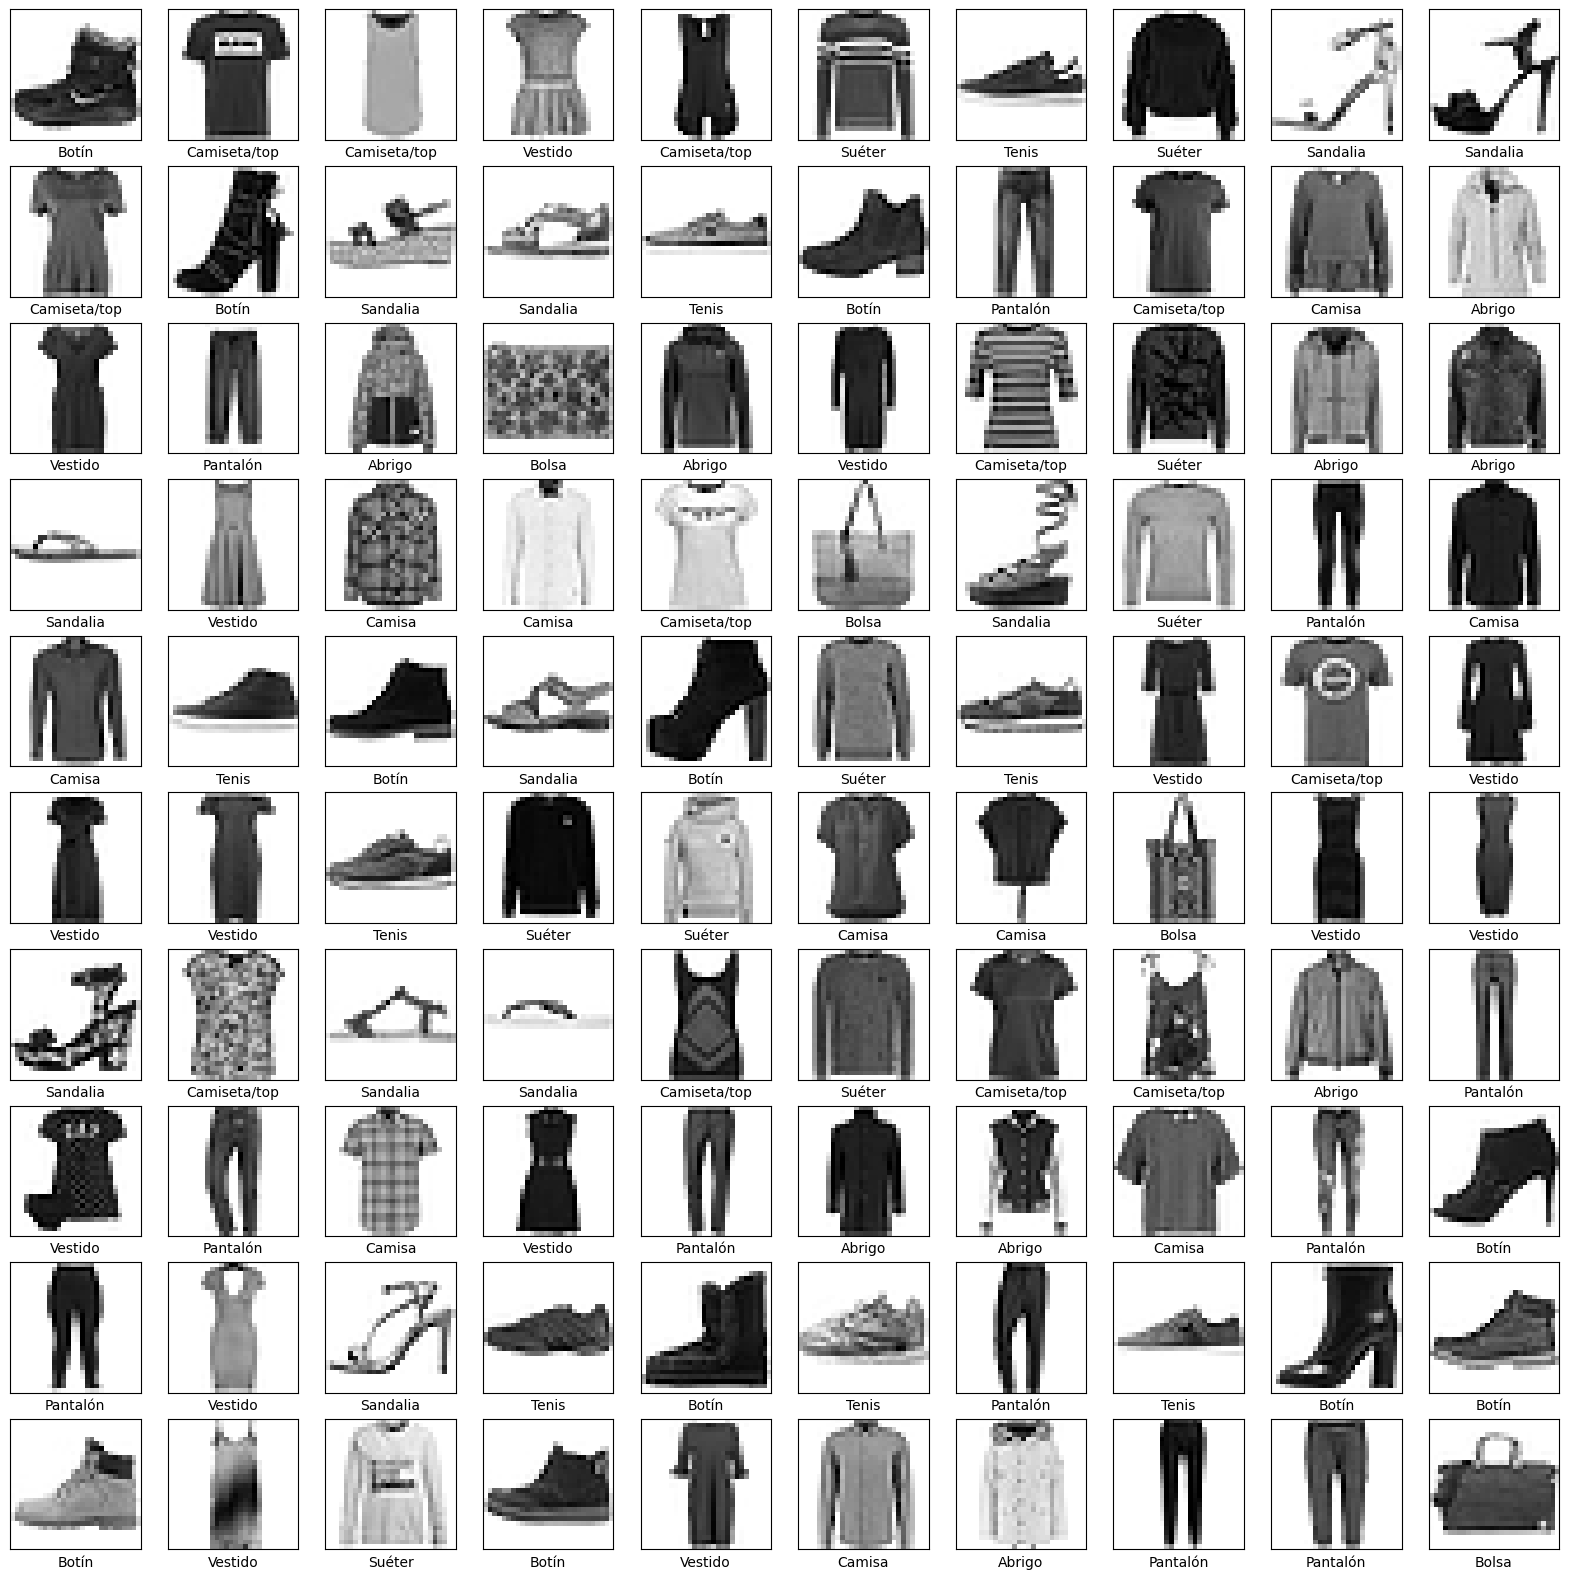

In [ ]:
plt.figure(figsize=(20,20))
for i in range(100):
  plt.subplot(10,10,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(train_images[i], cmap=plt.cm.binary)
  plt.xlabel(class_names[train_labels[i]])
plt.show()


In [ ]:
train_images[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

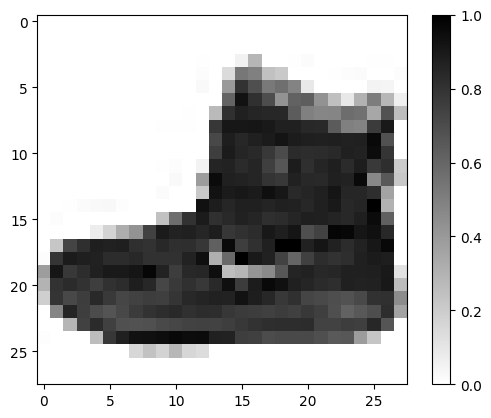

In [ ]:
plt.figure()
plt.imshow(train_images[0]/255, cmap=plt.cm.binary)
plt.colorbar()
plt.grid(False)
plt.show()

## Normalización de imáges

In [ ]:
train_images_N=train_images/255.0
test_images_N=test_images/255.0

## Modelo MLP con capas Dense

In [ ]:
model=keras.Sequential()
model.add(Input(shape=(28,28)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

In [ ]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

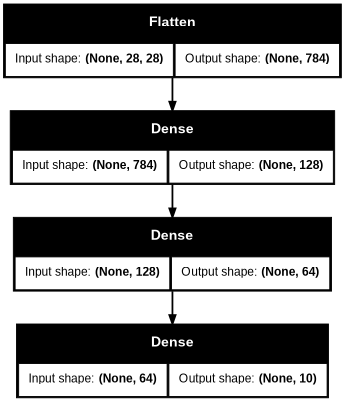

In [ ]:
plot_model(model, show_shapes=True, dpi=64)

In [ ]:
model2=keras.Sequential([
    Input(shape=(28,28)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

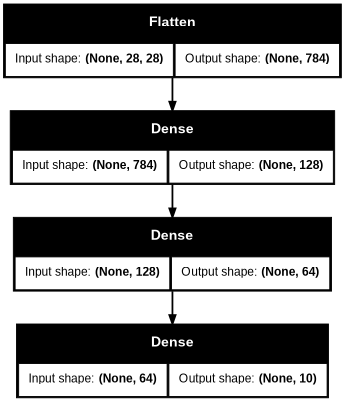

In [ ]:
plot_model(model2, show_shapes=True, dpi=64)

In [ ]:
x_input=Input(shape=(28,28))
x=Flatten()(x_input)
y=Dense(128, activation='relu')(x)

x1=Dense(128, activation='relu')(x)
x1=Dense(64, activation='relu')(x1)
x1=layers.Concatenate()([y,x1])
x_output=Dense(10, activation='softmax')(x1)
model3=keras.Model(inputs=x_input, outputs=x_output)

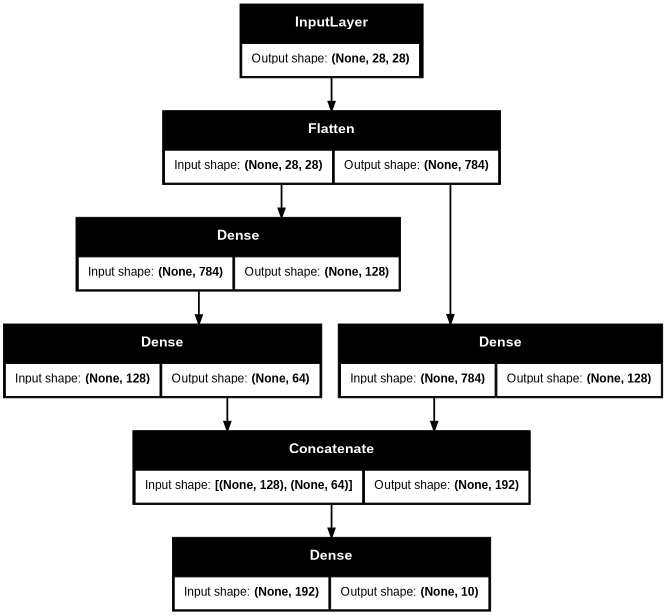

In [ ]:
plot_model(model3, show_shapes=True, dpi=64)

In [ ]:
model.compile(optimizer=Adam(learning_rate=0.003), loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history= model.fit(train_images_N, train_labels, epochs=15, validation_data=(test_images_N, test_labels))

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8253 - loss: 0.4866 - val_accuracy: 0.8353 - val_loss: 0.4610
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8608 - loss: 0.3812 - val_accuracy: 0.8606 - val_loss: 0.3889
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8716 - loss: 0.3489 - val_accuracy: 0.8707 - val_loss: 0.3670
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8786 - loss: 0.3303 - val_accuracy: 0.8623 - val_loss: 0.3832
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8840 - loss: 0.3137 - val_accuracy: 0.8605 - val_loss: 0.3854
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8879 - loss: 0.3025 - val_accuracy: 0.8661 - val_loss: 0.3803
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8903 - loss: 0.2966 - val_accuracy: 0.8698 - val_loss: 0.3674
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8934 - loss: 0.2847 - 

Text(0.5, 1.0, 'Training and validation Loss')

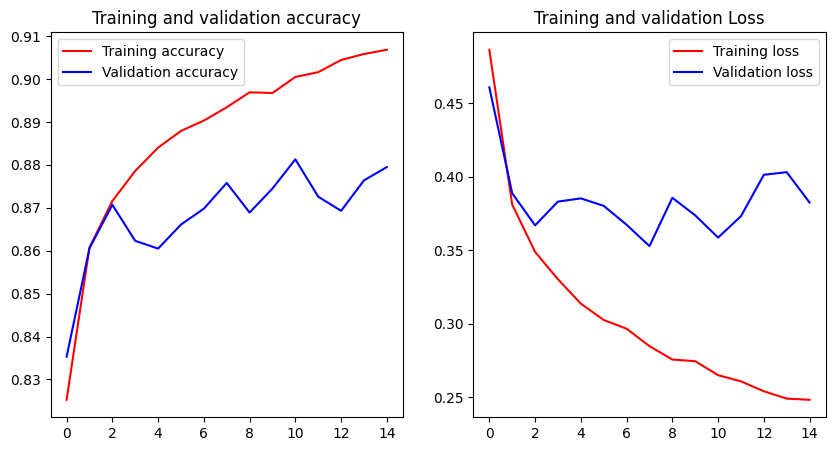

In [ ]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(len(acc))
f, ax= plt.subplots(1,2, figsize=(10,5))
ax[0].plot(epochs, acc, 'r', label='Training accuracy')
ax[0].plot(epochs, val_acc, 'b', label='Validation accuracy')
ax[0].set_title('Training and validation accuracy')
ax[0].legend()
ax[1].plot(epochs, loss, 'r', label='Training loss')
ax[1].plot(epochs, val_loss, 'b', label='Validation loss')
ax[1].set_title('Training and validation loss')
ax[1].legend()
ax[1].set_title('Training and validation Loss')


In [ ]:
model.evaluate(test_images_N, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8795 - loss: 0.3826


[0.38255199790000916, 0.8794999718666077]

In [ ]:
test_images_N.shape

(10000, 28, 28)

In [ ]:
test_images_N[0].shape

(28, 28)

In [ ]:
predictions= model.predict(test_images_N)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [ ]:
predictions[0]

array([2.9065456e-18, 4.2542911e-17, 2.3768345e-20, 1.1781743e-13,
       9.5919493e-17, 6.1176245e-08, 1.9392730e-19, 2.9825764e-03,
       7.1593447e-14, 9.9701738e-01], dtype=float32)

In [ ]:
np.max(predictions[0])

np.float32(0.9970174)

In [ ]:
class_names[np.argmax(predictions[0])]

'Botín'

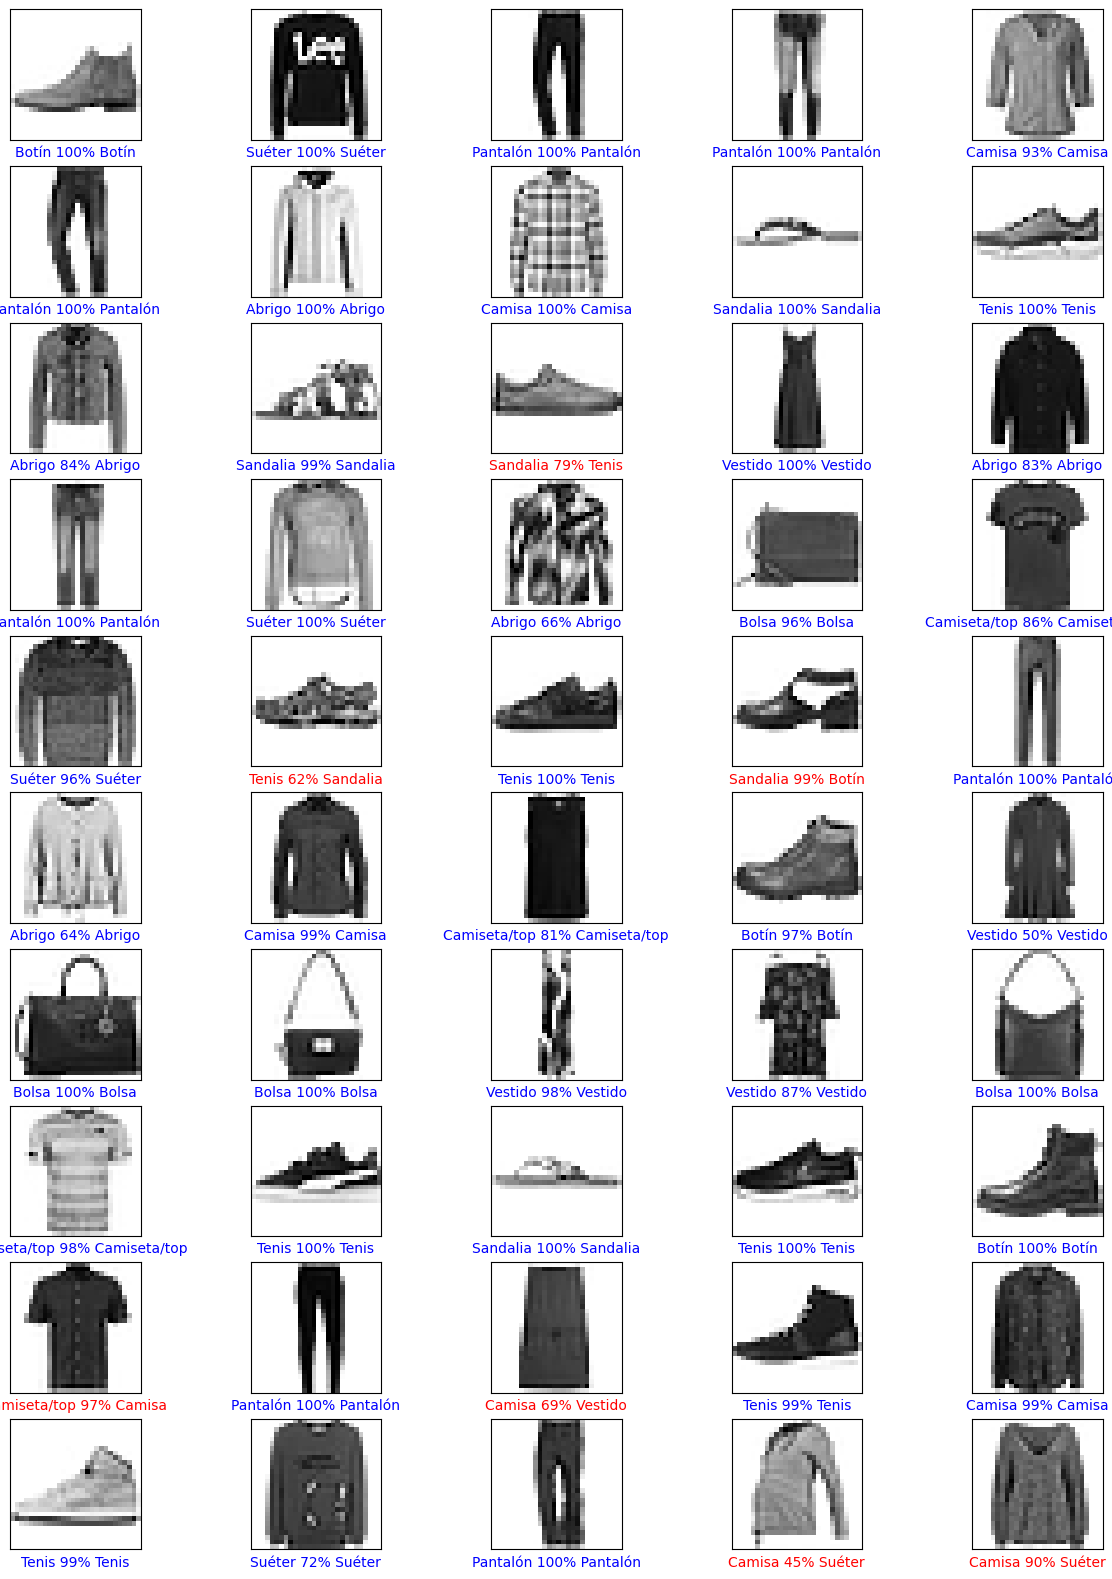

In [ ]:
plt.figure(figsize=(15,20))
for i in range(50):
  plt.subplot(10,5,i+1)
  plt.xticks([])
  plt.yticks([])
  plt.grid(False)
  plt.imshow(test_images[i], cmap=plt.cm.binary)
  predict_label=np.argmax(predictions[i])
  if (predict_label==test_labels[i]):
    color='blue'
  else:
    color='red'
  plt.xlabel("{} {:2.0f}% {}".format(class_names[predict_label],
                               100*np.max(predictions[i]),
                               class_names[test_labels[i]]),
             color=color)
plt.show()

In [ ]:
train_images_N[0].shape

(28, 28)

In [ ]:
img=np.expand_dims(train_images_N[0],axis=0)
img.shape

(1, 28, 28)

In [ ]:
p=model.predict(img)
p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step


array([[1.0906888e-19, 6.9272380e-19, 6.0443184e-22, 7.7377801e-14,
        2.1966234e-18, 1.5042046e-08, 4.6099389e-21, 8.0044818e-04,
        2.4558011e-15, 9.9919957e-01]], dtype=float32)

In [ ]:
class_names[np.argmax(p)]

'Botín'

## Ejemplo con redes convolucionales

In [ ]:
train_images_N.shape

(60000, 28, 28)

In [ ]:
x_train=np.expand_dims(train_images_N, axis=3)
x_test=np.expand_dims(test_images_N, axis=3)

In [ ]:
x_train.shape

(60000, 28, 28, 1)

In [ ]:
modelCV=keras.Sequential()
modelCV.add(Input(shape=(28,28,1)))
modelCV.add(Conv2D(64,(3,3),activation='relu'))
modelCV.add(Conv2D(64,(3,3),activation='relu'))
modelCV.add(MaxPooling2D((2,2)))
modelCV.add(Conv2D(32,(3,3),activation='relu'))
modelCV.add(Conv2D(32,(3,3),activation='relu'))
modelCV.add(MaxPooling2D((2,2)))
modelCV.add(Flatten())
modelCV.add(Dense(128, activation='relu'))
modelCV.add(Dense(10, activation='softmax'))

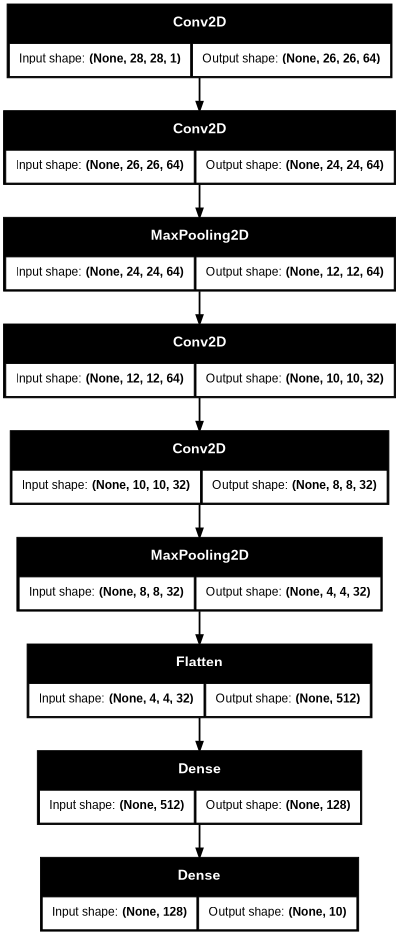

In [ ]:
plot_model(modelCV, show_shapes=True, dpi=64)

In [ ]:
modelCV.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history= modelCV.fit(x_train, train_labels, epochs=15, validation_data=(x_test, test_labels))

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.8330 - loss: 0.4551 - val_accuracy: 0.8657 - val_loss: 0.3656
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8946 - loss: 0.2900 - val_accuracy: 0.8936 - val_loss: 0.2926
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9092 - loss: 0.2487 - val_accuracy: 0.9022 - val_loss: 0.2683
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9188 - loss: 0.2226 - val_accuracy: 0.9005 - val_loss: 0.2756
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9265 - loss: 0.2002 - val_accuracy: 0.9163 - val_loss: 0.2334
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9316 - loss: 0.1825 - val_accuracy: 0.9083 - val_loss: 0.2538
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9377 - loss: 0.1676 - val_accuracy: 0.9152 - val_loss: 0.2399
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9432 - loss: 0.1524 

Text(0.5, 1.0, 'Training and validation Loss')

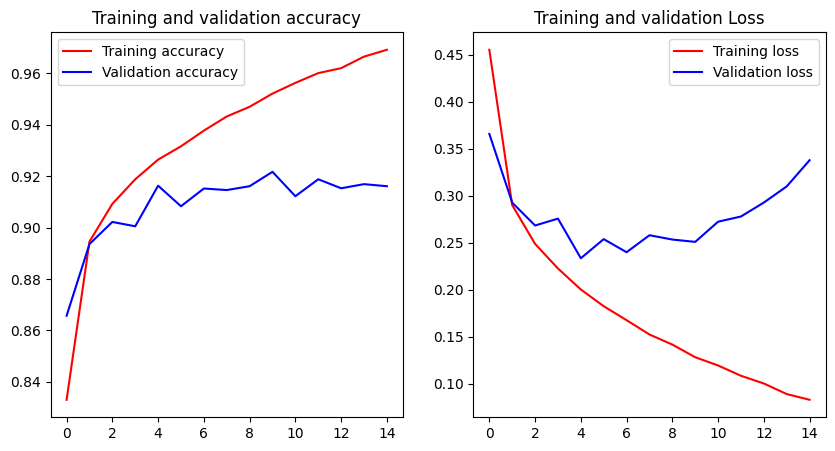

In [ ]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(len(acc))
f, ax= plt.subplots(1,2, figsize=(10,5))
ax[0].plot(epochs, acc, 'r', label='Training accuracy')
ax[0].plot(epochs, val_acc, 'b', label='Validation accuracy')
ax[0].set_title('Training and validation accuracy')
ax[0].legend()
ax[1].plot(epochs, loss, 'r', label='Training loss')
ax[1].plot(epochs, val_loss, 'b', label='Validation loss')
ax[1].set_title('Training and validation loss')
ax[1].legend()
ax[1].set_title('Training and validation Loss')

In [ ]:
modelCV=keras.Sequential()
modelCV.add(Input(shape=(28,28,1)))
modelCV.add(Conv2D(64,(3,3),use_bias=False))
modelCV.add(BatchNormalization())
modelCV.add(Activation('relu'))
modelCV.add(Conv2D(64,(3,3),use_bias=False))
modelCV.add(BatchNormalization())
modelCV.add(Activation('relu'))
modelCV.add(MaxPooling2D((2,2)))
modelCV.add(Dropout(0.25))
modelCV.add(Conv2D(32,(3,3),use_bias=False))
modelCV.add(BatchNormalization())
modelCV.add(Activation('relu'))
modelCV.add(Conv2D(32,(3,3),use_bias=False))
modelCV.add(BatchNormalization())
modelCV.add(Activation('relu'))
modelCV.add(MaxPooling2D((2,2)))
modelCV.add(Dropout(0.25))
modelCV.add(Flatten())
modelCV.add(Dense(128, activation='relu'))
modelCV.add(Dropout(0.3))
modelCV.add(Dense(10, activation='softmax'))

In [ ]:
modelCV.compile(optimizer=Adam(learning_rate=0.001), loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
history= modelCV.fit(x_train, train_labels, epochs=15, validation_data=(x_test, test_labels))

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.7974 - loss: 0.5535 - val_accuracy: 0.8693 - val_loss: 0.3616
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8698 - loss: 0.3595 - val_accuracy: 0.8896 - val_loss: 0.2978
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8844 - loss: 0.3170 - val_accuracy: 0.8920 - val_loss: 0.2799
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8913 - loss: 0.2935 - val_accuracy: 0.9068 - val_loss: 0.2569
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9006 - loss: 0.2720 - val_accuracy: 0.9089 - val_loss: 0.2485
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9042 - loss: 0.2591 - val_accuracy: 0.9039 - val_loss: 0.2588
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9083 - loss: 0.2505 - val_accuracy: 0.9135 - val_loss: 0.2389
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9126 - loss: 0.

Text(0.5, 1.0, 'Training and validation Loss')

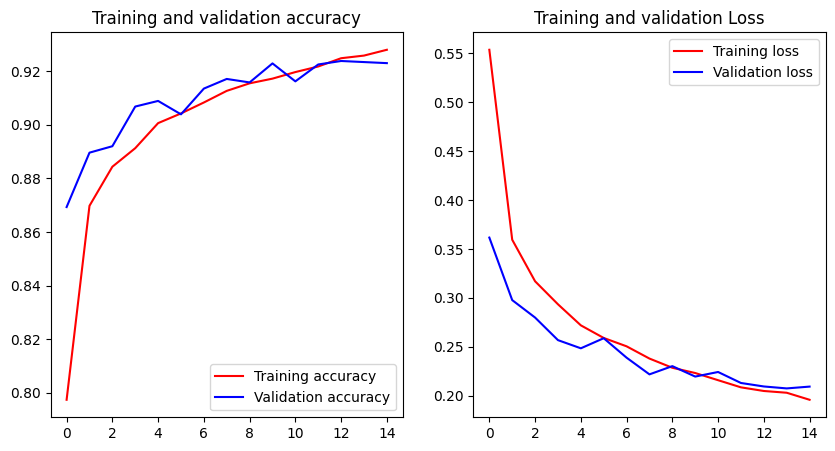

In [ ]:
acc=history.history['accuracy']
val_acc=history.history['val_accuracy']
loss=history.history['loss']
val_loss=history.history['val_loss']
epochs=range(len(acc))
f, ax= plt.subplots(1,2, figsize=(10,5))
ax[0].plot(epochs, acc, 'r', label='Training accuracy')
ax[0].plot(epochs, val_acc, 'b', label='Validation accuracy')
ax[0].set_title('Training and validation accuracy')
ax[0].legend()
ax[1].plot(epochs, loss, 'r', label='Training loss')
ax[1].plot(epochs, val_loss, 'b', label='Validation loss')
ax[1].set_title('Training and validation loss')
ax[1].legend()
ax[1].set_title('Training and validation Loss')

In [ ]:
predictions= modelCV.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


In [ ]:
predictions.shape

(10000, 10)

In [ ]:
predictions[0]

array([2.7753434e-14, 4.7394818e-16, 2.3747253e-13, 5.4219161e-16,
       6.5010497e-13, 4.1817319e-07, 3.2991225e-14, 2.2764723e-06,
       2.2122832e-14, 9.9999726e-01], dtype=float32)

In [ ]:
labels_prediction=np.argmax(predictions, axis=1)
labels_prediction

array([9, 2, 1, ..., 8, 1, 5])

In [ ]:
test_labels

array([9, 2, 1, ..., 8, 1, 5], dtype=uint8)

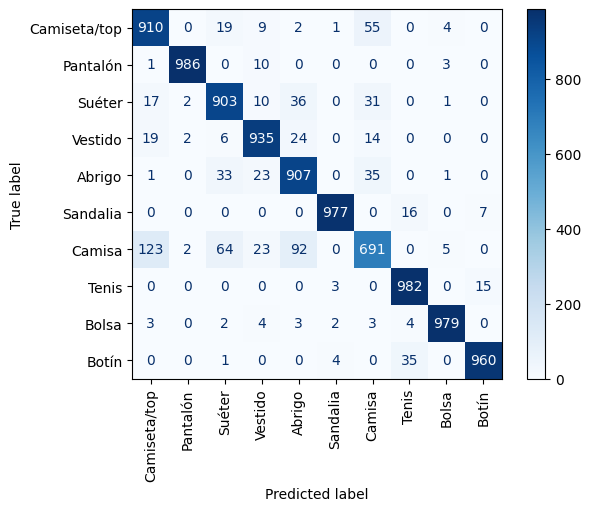

In [ ]:
cm=confusion_matrix(test_labels, labels_prediction)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(cmap='Blues', xticks_rotation='vertical')

In [ ]:
print(classification_report(test_labels, labels_prediction, target_names=class_names))

              precision    recall  f1-score   support

Camiseta/top       0.85      0.91      0.88      1000
    Pantalón       0.99      0.99      0.99      1000
      Suéter       0.88      0.90      0.89      1000
     Vestido       0.92      0.94      0.93      1000
      Abrigo       0.85      0.91      0.88      1000
    Sandalia       0.99      0.98      0.98      1000
      Camisa       0.83      0.69      0.76      1000
       Tenis       0.95      0.98      0.96      1000
       Bolsa       0.99      0.98      0.98      1000
       Botín       0.98      0.96      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000

